In [1]:
from detprocess import Noise, Template
import matplotlib.pyplot as plt
from qetpy.utils import fft, ifft, fftfreq
import numpy as np
import cloudpickle
def twopole(t,taurise, taufall, A, t_0):
    thing = A*(np.exp(-(t-t_0)/taufall) - np.exp(-(t-t_0)/taurise))
    return np.where(thing > 0 , thing, 0)


## PSD Definions
Not explicitly used, but users can use this to play around with sampling noise absent cross-channel correlation

## LEE PDFs
These are the energy (really amplitude) distributions from which we'll be sampling our low energy excess. In this case, they're just normal distributions of differing mean, once again chose to emphasize the difference between singles and shared low energy excess. Note that that PDF_tags stated in the yaml file correspond to the keys in which each function is stored in the pkl file

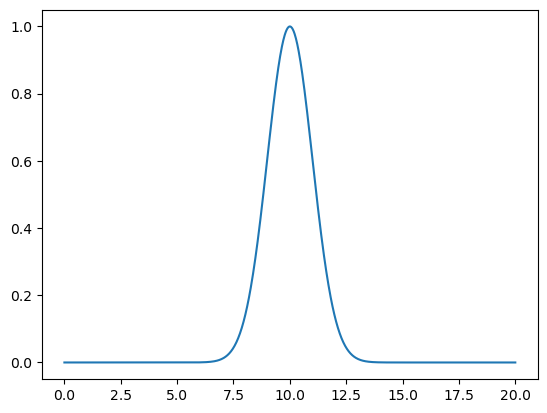

In [ ]:
# def pdf(x):
#     return 1-(x/100)**2

def pdf_single(x):
    return np.exp(-(x-7.5)**2/(2))

def pdf_shared(x):
    return np.exp(-(x-12.5)**2/(2))

xdata = np.linspace(0, 20, 1000)

fig, ax = plt.subplots()
ax.plot(xdata, pdf_single(xdata))
ax.plot(xdata, pdf_shared(xdata))

pdf_dict = {}

pdf_dict['LEE_single'] = pdf_single
pdf_dict['LEE_shared'] = pdf_shared

with open('LEE_PDF.pkl', 'wb') as f:
    cloudpickle.dump(pdf_dict, f)

## 2-channel; CSD
Here we're defining our noise based noise seen in a previous LBL run. Feel free to use any dataset available for this, or to define your own CSD explicitly manually, using the noisetest.set_csd() function

In [7]:
noisetest = Noise()


noisetest.generate_randoms(raw_path = '/data/lbl/run21/raw/continuous_I4_D20241218_T175814/',
                           nevents = 4000
                           )

noisetest.calc_csd(channels = ['MV4_1_I4_E_2ch1pc_left', 'MV4_1_I4_E_2ch1pc_right'],
                   trace_length_msec = 20,
                   pretrigger_length_msec = 5, 
                   nevents = 4000)

INFO: Building file map for raw data group continuous_I4_D20241218_T175814
INFO: Total raw data duration = 30.016666666666666 minutes (1801 events)
INFO Node #1: Acquiring randoms for series I4_D20241218_T175829
INFO Node #1: Acquiring randoms for series I4_D20241218_T180849
INFO Node #1: Acquiring randoms for series I4_D20241218_T181909
INFO: Randoms acquisition done!
INFO: Number of events after cuts = 271, efficiency = 7.52%


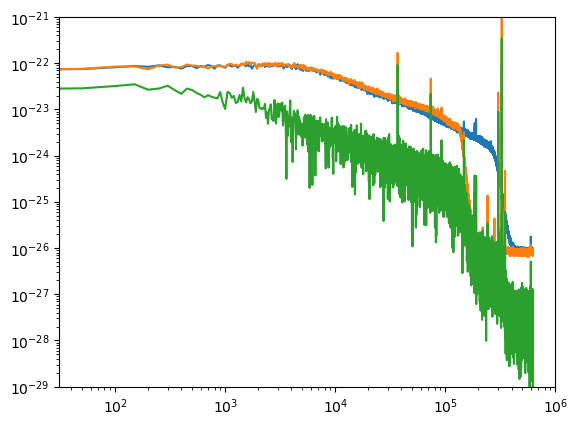

In [8]:
CSD, _ = noisetest.get_csd(channels = ['MV4_1_I4_E_2ch1pc_left', 'MV4_1_I4_E_2ch1pc_right'])
freqs = np.fft.fftfreq(CSD.shape[-1], 1/1.25e6)
fig, ax = plt.subplots()
cutoff = int(len(freqs)/2)
ax.plot(freqs[0:cutoff], CSD[0,0,0:cutoff])
ax.plot(freqs[0:cutoff], CSD[1,1,0:cutoff])
ax.plot(freqs[0:cutoff], np.abs(CSD[0,1,0:cutoff]))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-29,1e-21)

noise2 = Noise()

noise2.set_csd(csd = CSD,
               channels = ['channel_00', 'channel_01'],
               sample_rate = 1.25e6,
               pretrigger_length_msec=5,
               csd_freqs = freqs)


## Defining Templates
Defining singles and shared LEE templates for the two channels. The former are a pair of 1x1 templates, optimistically defined as identical for the two QETs. The latter is a 2x1 template to reflect the presumed perfect correlation in amplitudes between the two QETs for phonon-mediated events

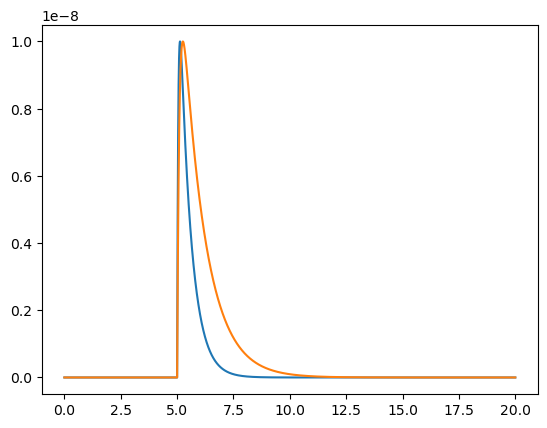

In [9]:
template2 = Template()

tdata = np.arange(int(20*1.25e3))/1.25e3

singles_template = twopole(tdata, .05, .5, 1, 5)
shared_template = twopole(tdata, .1, 1, 1, 5)
singles_template /= max(singles_template)
shared_template /= max(shared_template)

singles_template *= 1e-8
shared_template *= 1e-8

zeros = np.zeros_like(singles_template)


shared_2x2 = np.array([[shared_template],
                       [shared_template]])

fig, ax = plt.subplots()
ax.plot(tdata, singles_template)
ax.plot(tdata, shared_template)

template2.set_template(channels = 'channel_00',
                       template = singles_template,
                       pretrigger_length_msec=5,
                       tag = 'LEE_single',
                       sample_rate=1.25e6)

template2.set_template(channels = 'channel_01',
                       template = singles_template,
                       pretrigger_length_msec=5,
                       tag = 'LEE_single',
                       sample_rate=1.25e6)

template2.set_template(channels = ['channel_00', 'channel_01'],
                       template = shared_2x2,
                       pretrigger_length_msec=5,
                       tag = 'LEE_shared',
                       sample_rate=1.25e6)


In [10]:
noise2.save_hdf5('CSD_filterfile.hdf5', overwrite = True)
template2.save_hdf5('CSD_filterfile.hdf5', overwrite = True)

INFO: Saving filter/TES data to file CSD_filterfile.hdf5! (overwrite=True)
INFO: Saving filter/TES data to file CSD_filterfile.hdf5! (overwrite=True)


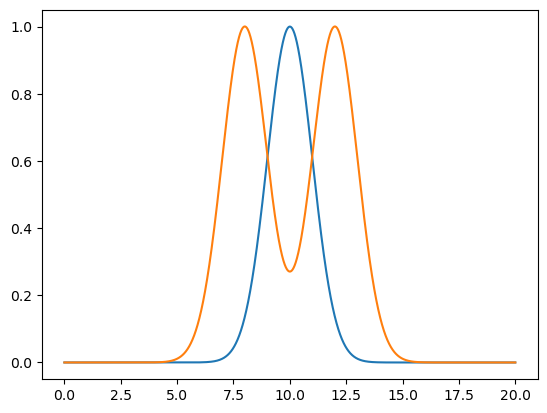

In [ ]:
def single_pdf(x):
    return np.exp(-(x-10)**2/2)

def shared_pdf(x):
    return np.exp(-(x-8)**2/2) + np.exp(-(x-12)**2/2)
tdata= np.linspace(0,20, 10000)

fig, ax = plt.subplots()
ax.plot(tdata, single_pdf(tdata))
ax.plot(tdata, shared_pdf(tdata))


pdf_dict = {}

pdf_dict['LEE_single'] = single_pdf
pdf_dict['LEE_shared'] = shared_pdf

with open('LEE_PDF.pkl', 'wb') as f:
    cloudpickle.dump(pdf_dict, f)